In [ ]:
!pip install spikingjelly -q
!pip install decord -q
!pip install brian2 -q
import os
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms
from PIL import Image
from spikingjelly.activation_based import base, layer, neuron, surrogate, functional
import pandas as pd
from pathlib import Path
import random
from torch.utils.data import Dataset, DataLoader
from decord import VideoReader, cpu
import decord
from random import choice
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import itertools
from brian2 import *

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 7.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 85.1 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is inco

In [ ]:
class ConvRecurrentContainer(base.MemoryModule):
    def __init__(self, sub_module, in_channels, out_channels, stride, step_mode="s"):
        super().__init__()
        self.step_mode = step_mode
        assert not hasattr(sub_module, "step_mode") or sub_module.step_mode == "s"
        self.sub_module_out_channels = out_channels
        self.sub_module = sub_module

        if stride > 1:
            self.dwconv = nn.ConvTranspose2d(
                out_channels, out_channels,
                kernel_size=3, stride=stride,
                padding=1, output_padding=1,
                groups=out_channels, bias=False
            )
            self.bn1 = layer.BatchNorm2d(out_channels)
            self.sn1 = neuron.LIFNode(
                surrogate_function=surrogate.ATan(),
                detach_reset=True
            )
        else:
            self.dwconv = None

        self.pwconv = nn.Conv2d(
            in_channels + out_channels,
            in_channels,
            kernel_size=1, stride=1, bias=False
        )
        self.bn = layer.BatchNorm2d(in_channels)
        self.sn = neuron.LIFNode(
            surrogate_function=surrogate.ATan(),
            detach_reset=True
        )

        self.register_memory("y", None)

    def single_step_forward(self, x):
        if self.y is None:
            if self.dwconv is None:
                self.y = torch.zeros(
                    x.size(0), self.sub_module_out_channels, x.size(2), x.size(3),
                    device=x.device, dtype=x.dtype
                )
            else:
                h = (x.size(2) + 2 - (3 - 1) - 1) // 2 + 1
                w = (x.size(3) + 2 - (3 - 1) - 1) // 2 + 1
                self.y = torch.zeros(
                    x.size(0), self.sub_module_out_channels, h, w,
                    device=x.device, dtype=x.dtype
                )

        if self.dwconv is None:
            out = self.y
        else:
            out = self.sn1(self.bn1(self.dwconv(self.y)))

        out = torch.cat((x, out), dim=1)
        out = self.bn(self.pwconv(out))
        out = self.sn(out)
        self.y = self.sub_module(out)

        return self.y


def sew_function(x, y, cnf):
    if cnf == "ADD":
        return x + y
    elif cnf == "AND":
        return x * y
    elif cnf == "OR":
        return x + y - x * y
    else:
        raise NotImplementedError


def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    return layer.Conv2d(
        in_planes, out_planes, kernel_size=3, stride=stride,
        padding=dilation, groups=groups, bias=False, dilation=dilation
    )


def conv1x1(in_planes, out_planes, stride=1):
    return layer.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, norm_layer=None, cnf=None):
        super().__init__()
        if norm_layer is None:
            norm_layer = layer.BatchNorm2d

        if groups != 1 or base_width != 64:
            raise ValueError("BasicBlock only supports groups=1 and base_width=64")

        self.conv1 = conv3x3(in_planes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.sn1 = neuron.LIFNode(
            surrogate_function=surrogate.ATan(),
            detach_reset=True
        )

        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.sn2 = neuron.LIFNode(
            surrogate_function=surrogate.ATan(),
            detach_reset=True
        )

        self.downsample = downsample
        if downsample is not None:
            self.downsample_sn = neuron.LIFNode(
                surrogate_function=surrogate.ATan(),
                detach_reset=True
            )

        self.stride = stride
        self.cnf = cnf

    def forward(self, x):
        identity = x

        out = self.sn1(self.bn1(self.conv1(x)))
        out = self.sn2(self.bn2(self.conv2(out)))

        if self.downsample is not None:
            identity = self.downsample_sn(self.downsample(x))

        out = sew_function(out, identity, self.cnf)
        return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_planes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, norm_layer=None, cnf=None):
        super().__init__()
        if norm_layer is None:
            norm_layer = layer.BatchNorm2d

        width = int(planes * (base_width / 64.0)) * groups

        self.conv1 = conv1x1(in_planes, width)
        self.bn1 = norm_layer(width)
        self.sn1 = neuron.LIFNode(
            surrogate_function=surrogate.ATan(),
            detach_reset=True
        )

        self.conv2 = conv3x3(width, width, stride, groups)
        self.bn2 = norm_layer(width)
        self.sn2 = neuron.LIFNode(
            surrogate_function=surrogate.ATan(),
            detach_reset=True
        )

        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3 = norm_layer(planes * self.expansion)
        self.sn3 = neuron.LIFNode(
            surrogate_function=surrogate.ATan(),
            detach_reset=True
        )

        self.downsample = downsample
        if downsample is not None:
            self.downsample_sn = neuron.LIFNode(
                surrogate_function=surrogate.ATan(),
                detach_reset=True
            )

        self.stride = stride
        self.cnf = cnf

    def forward(self, x):
        identity = x

        out = self.sn1(self.bn1(self.conv1(x)))
        out = self.sn2(self.bn2(self.conv2(out)))
        out = self.sn3(self.bn3(self.conv3(out)))

        if self.downsample is not None:
            identity = self.downsample_sn(self.downsample(x))

        out = sew_function(out, identity, self.cnf)
        return out


class LoRaFBSNet(nn.Module):
    def __init__(self, block, layers, num_classes=10, groups=1, width_per_groups=64,
                 norm_layer=None, cnf="ADD", zero_init_residual=False):
        super().__init__()

        if norm_layer is None:
            norm_layer = layer.BatchNorm2d
        self._norm_layer = norm_layer

        self.in_planes = 64
        self.groups = groups
        self.base_width = width_per_groups

        self.conv1 = layer.Conv2d(1, self.in_planes, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = self._norm_layer(self.in_planes)
        self.sn1 = neuron.LIFNode(surrogate_function=surrogate.ATan(), detach_reset=True)
        self.maxpool = layer.MaxPool2d(kernel_size=3, stride=2, padding=1)

        layer1 = self._make_layer(block, 64, layers[0], cnf=cnf)
        self.recurrent_layer1 = ConvRecurrentContainer(
            layer1, in_channels=64, out_channels=64 * block.expansion, stride=1
        )

        layer2 = self._make_layer(block, 128, layers[1], stride=2, cnf=cnf)
        self.recurrent_layer2 = ConvRecurrentContainer(
            layer2, in_channels=64 * block.expansion,
            out_channels=128 * block.expansion, stride=2
        )

        layer3 = self._make_layer(block, 256, layers[2], stride=2, cnf=cnf)
        self.recurrent_layer3 = ConvRecurrentContainer(
            layer3, in_channels=128 * block.expansion,
            out_channels=256 * block.expansion, stride=2
        )

        layer4 = self._make_layer(block, 512, layers[3], stride=2, cnf=cnf)
        self.recurrent_layer4 = ConvRecurrentContainer(
            layer4, in_channels=256 * block.expansion,
            out_channels=512 * block.expansion, stride=2
        )

        self.avgpool = layer.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)


        for m in self.modules():
            if isinstance(m, (layer.Conv2d, nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, layer.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def _make_layer(self, block, planes, num_blocks, stride=1, cnf=None):
        downsample = None
        if stride != 1 or self.in_planes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.in_planes, planes * block.expansion, stride),
                self._norm_layer(planes * block.expansion)
            )

        layers_list = [
            block(
                self.in_planes, planes, stride, downsample,
                self.groups, self.base_width, self._norm_layer, cnf
            )
        ]

        self.in_planes = planes * block.expansion

        for _ in range(1, num_blocks):
            layers_list.append(
                block(
                    self.in_planes, planes,
                    groups=self.groups,
                    base_width=self.base_width,
                    norm_layer=self._norm_layer,
                    cnf=cnf
                )
            )

        return nn.Sequential(*layers_list)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.sn1(x)
        x = self.maxpool(x)

        x = self.recurrent_layer1(x)
        x = self.recurrent_layer2(x)
        x = self.recurrent_layer3(x)
        x = self.recurrent_layer4(x)

        x = self.avgpool(x)

        if self.avgpool.step_mode == 's':
            x = torch.flatten(x, 1)
        elif self.avgpool.step_mode == 'm':
            x = torch.flatten(x, 2)

        x = self.fc(x)
        return x



def lorafb_snet18(**kwargs):
    return LoRaFBSNet(BasicBlock, [2, 2, 2, 2], **kwargs)

In [ ]:
DATA_ROOT = Path("/kaggle/input/datasets/matthewjansen/ucf101-action-recognition")

train_df = pd.read_csv(DATA_ROOT / "train.csv")
val_df   = pd.read_csv(DATA_ROOT / "val.csv")
test_df  = pd.read_csv(DATA_ROOT / "test.csv")

print("Columns:", train_df.columns.tolist())
print(train_df.head())


def resolve_columns(df):
    """Find the path/label columns without hardcoding exact names — Kaggle
    occasionally tweaks CSV headers between dataset versions."""
    path_col = next(c for c in df.columns if "path" in c.lower())
    label_col = next(c for c in df.columns if "label" in c.lower())
    return path_col, label_col


PATH_COL, LABEL_COL = resolve_columns(train_df)
print(f"Using path column = '{PATH_COL}', label column = '{LABEL_COL}'")

CLASSES = sorted(train_df[LABEL_COL].unique().tolist())
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

print(f"{NUM_CLASSES} action classes")
print(f"train/val/test sizes: {len(train_df)}/{len(val_df)}/{len(test_df)}")


sample_path = DATA_ROOT / train_df[PATH_COL].iloc[0].lstrip("/")
print("Sample clip path:", sample_path, "| exists:", sample_path.exists())

Columns: ['clip_name', 'clip_path', 'label']
         clip_name                         clip_path  label
0  v_Swing_g05_c02  /train/Swing/v_Swing_g05_c02.avi  Swing
1  v_Swing_g21_c03  /train/Swing/v_Swing_g21_c03.avi  Swing
2  v_Swing_g07_c01  /train/Swing/v_Swing_g07_c01.avi  Swing
3  v_Swing_g24_c04  /train/Swing/v_Swing_g24_c04.avi  Swing
4  v_Swing_g20_c03  /train/Swing/v_Swing_g20_c03.avi  Swing
Using path column = 'clip_path', label column = 'label'
101 action classes
train/val/test sizes: 10055/1673/1723
Sample clip path: /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/train/Swing/v_Swing_g05_c02.avi | exists: True


========== Binary UCF101 ==========
Classes: ('Basketball', 'Diving')

Train counts:
label
Basketball    198
Diving        112
Name: count, dtype: int64

Val counts:
label
Basketball    33
Diving        19
Name: count, dtype: int64

Test counts:
label
Basketball    34
Diving        19
Name: count, dtype: int64


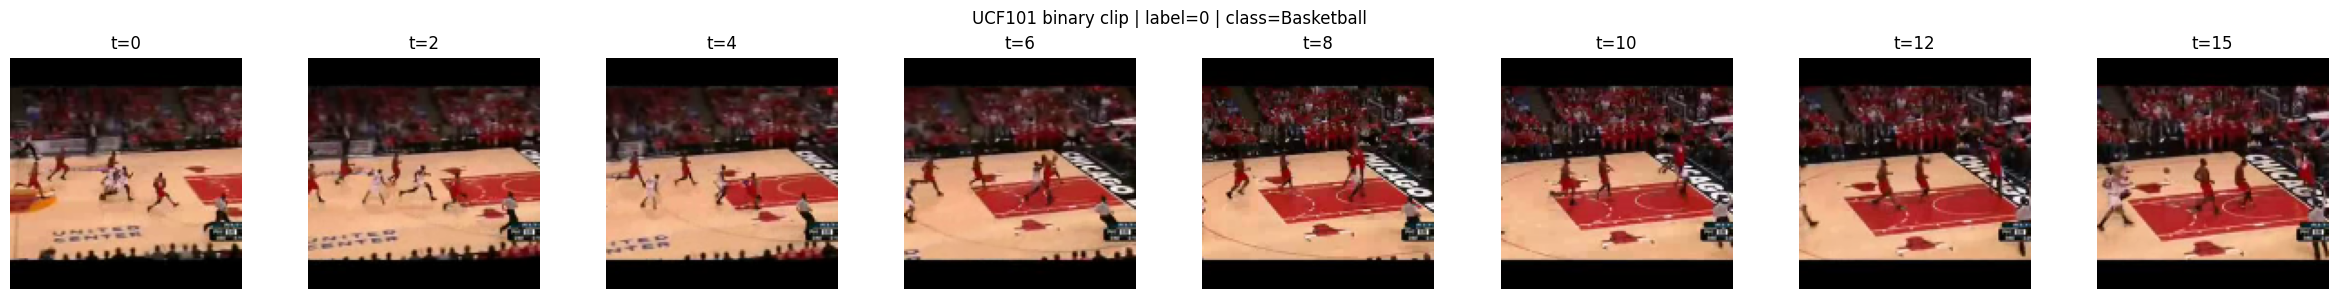

In [ ]:

decord.bridge.set_bridge('torch')
import torchvision.transforms.functional as TF

# =========================================================
# 1) Utility: detect path / label columns automatically
# =========================================================
def resolve_columns(df):
    path_col = next(c for c in df.columns if "path" in c.lower())
    label_col = next(c for c in df.columns if "label" in c.lower())
    return path_col, label_col


# =========================================================
# 2) 3-Class filtering helper
# =========================================================
def make_3classes_dataset(train_df, val_df, test_df, label_col, target_classes):
    """
    Keep only target classes from train/val/test dataframes.
    """
    assert len(target_classes) == 3, "target_classes must contain exactly 3 class names"

    train_df = train_df[train_df[label_col].isin(target_classes)].copy()
    val_df   = val_df[val_df[label_col].isin(target_classes)].copy()
    test_df  = test_df[test_df[label_col].isin(target_classes)].copy()

    class_to_idx = {
        target_classes[0]: 0,
        target_classes[1]: 1,
        target_classes[2]: 2
    }
    idx_to_class = {0: target_classes[0], 1: target_classes[1], 2: target_classes[2]}

    return train_df, val_df, test_df, class_to_idx, idx_to_class


# =========================================================
# 3) Balancing helper
# =========================================================
def sample_per_class(df, label_col, n_per_class, seed=0):
    if n_per_class is None:
        n_per_class = df[label_col].value_counts().min()
    parts = []
    for _, g in df.groupby(label_col):
        sample_size = min(len(g),n_per_class)
        parts.append(g.sample(n = sample_size, random_state=seed))
    return pd.concat(parts, axis=0).reset_index(drop=True)


# =========================================================
# 4) Grayscale Dataset Class
# =========================================================
class UCF101ThreeClassGrayscaleDataset(Dataset):
    def __init__(
        self,
        df,
        root_dir,
        path_col,
        label_col,
        class_to_idx,
        num_frames=16,
        frame_size=112,
        mode="train",
    ):
        self.df = df.reset_index(drop=True)
        self.root_dir = Path(root_dir)
        self.path_col = path_col
        self.label_col = label_col
        self.class_to_idx = class_to_idx
        self.num_frames = num_frames
        self.frame_size = frame_size
        self.mode = mode

        self.paths = self.df[path_col].tolist()
        self.labels = [self.class_to_idx[l] for l in self.df[label_col].tolist()]

        # UPDATED: Single channel mean and std for Grayscale
        self.mean = torch.tensor([0.456]).view(1, 1, 1, 1)
        self.std  = torch.tensor([0.224]).view(1, 1, 1, 1)

    def __len__(self):
        return len(self.paths)

    def _sample_indices(self, total_frames):
        if total_frames <= 0:
            return np.zeros(self.num_frames, dtype=int)

        if total_frames < self.num_frames:
            idx = np.linspace(0, total_frames - 1, total_frames).astype(int)
            pad = np.full(self.num_frames - total_frames, total_frames - 1, dtype=int)
            return np.concatenate([idx, pad])

        if self.mode == "train":
            seg = total_frames / self.num_frames
            offsets = np.random.uniform(0, seg, size=self.num_frames)
            idx = (np.arange(self.num_frames) * seg + offsets).astype(int)
        else:
            idx = np.linspace(0, total_frames - 1, self.num_frames).astype(int)

        return np.clip(idx, 0, total_frames - 1)

    def _spatial_params(self, h, w):
        short = min(h, w)
        scale = self.frame_size / short

        new_h = max(int(round(h * scale)), self.frame_size)
        new_w = max(int(round(w * scale)), self.frame_size)

        if self.mode == "train":
            top = np.random.randint(0, new_h - self.frame_size + 1)
            left = np.random.randint(0, new_w - self.frame_size + 1)
            flip = bool(np.random.rand() < 0.5)
        else:
            top = (new_h - self.frame_size) // 2
            left = (new_w - self.frame_size) // 2
            flip = False

        return new_h, new_w, top, left, flip

    def __getitem__(self, idx):
        rel_path = str(self.paths[idx]).lstrip("/")
        video_path = self.root_dir / rel_path
        label = self.labels[idx]

        vr = VideoReader(str(video_path), ctx=cpu(0))
        total_frames = len(vr)

        frame_idx = self._sample_indices(total_frames)
        frames = vr.get_batch(frame_idx)   # shape: (T, H, W, C), torch uint8

        # Convert (T, H, W, C) -> (T, C, H, W) float tensor in [0, 1]
        clip = frames.permute(0, 3, 1, 2).float() / 255.0

        # UPDATED: Convert RGB to Grayscale -> Output Shape: (T, 1, H, W)
        clip = TF.rgb_to_grayscale(clip, num_output_channels=1)

        clip = clip.clamp(0.0, 1.0)
        
        T, C, H, W = clip.shape

        # Spatial Resize + Crop + Flip
        new_h, new_w, top, left, flip = self._spatial_params(H, W)

        clip = torch.nn.functional.interpolate(
            clip,
            size=(new_h, new_w),
            mode="bilinear",
            align_corners=False
        )

        clip = clip[:, :, top:top+self.frame_size, left:left+self.frame_size]

        if flip:
            clip = clip.flip(-1)

        # Normalize with 1-channel mean/std
        clip = (clip - self.mean) / self.std

        # Final shape: (T, 1, H, W)
        return clip, label


# =========================================================
# 5) Main loader builder
# =========================================================
# =========================================================
# 5) Main loader builder (Updated with Balancing)
# =========================================================
def prepare_ucf101_grayscale_loaders(
    data_root,
    target_classes=("Basketball", "Diving", "ApplyEyeMakeup"),
    num_frames=16,
    frame_size=96,
    batch_size=4,
    num_workers=2,
    debug=False,
    balance_splits=True,  # Automatically balance Train, Val, and Test
    train_per_class=None, # Leave None to auto-compute min count
    val_per_class=None,
    test_per_class=None,
    seed=0
):
    data_root = Path(data_root)

    train_df = pd.read_csv(data_root / "train.csv")
    val_df   = pd.read_csv(data_root / "val.csv")
    test_df  = pd.read_csv(data_root / "test.csv")

    path_col, label_col = resolve_columns(train_df)

    train_df, val_df, test_df, class_to_idx, idx_to_class = make_3classes_dataset(
        train_df, val_df, test_df, label_col, list(target_classes)
    )

    # ---------------------------------------------------------
    # Perform Dataset Balancing Across All Splits
    # ---------------------------------------------------------
    if balance_splits or debug:
        train_df = sample_per_class(train_df, label_col, n_per_class=train_per_class, seed=seed)
        val_df   = sample_per_class(val_df, label_col, n_per_class=val_per_class, seed=seed)
        test_df  = sample_per_class(test_df, label_col, n_per_class=test_per_class, seed=seed)

    print("========== 3-Class Grayscale UCF101 (Balanced) ==========")
    print("Classes:", target_classes)
    print("\nTrain counts:\n", train_df[label_col].value_counts())
    print("\nVal counts:\n", val_df[label_col].value_counts())
    print("\nTest counts:\n", test_df[label_col].value_counts())

    train_ds = UCF101ThreeClassGrayscaleDataset(
        train_df, root_dir=data_root, path_col=path_col, label_col=label_col,
        class_to_idx=class_to_idx, num_frames=num_frames, frame_size=frame_size, mode="train"
    )

    val_ds = UCF101ThreeClassGrayscaleDataset(
        val_df, root_dir=data_root, path_col=path_col, label_col=label_col,
        class_to_idx=class_to_idx, num_frames=num_frames, frame_size=frame_size, mode="val"
    )

    test_ds = UCF101ThreeClassGrayscaleDataset(
        test_df, root_dir=data_root, path_col=path_col, label_col=label_col,
        class_to_idx=class_to_idx, num_frames=num_frames, frame_size=frame_size, mode="test"
    )

    common = dict(
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=(num_workers > 0)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True, **common)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, **common)
    test_loader  = DataLoader(test_ds, batch_size=4, shuffle=False, num_workers=0, pin_memory=False)

    return train_loader, val_loader, test_loader, class_to_idx, idx_to_class


# =========================================================
# 6) Visualization Helper Updated for Grayscale
# =========================================================
def show_ucf_clip_sample_with_class(dataset, idx_to_class, sample_idx=0, n_show=6, title_prefix="Sample"):
    clip, label = dataset[sample_idx]  # Shape: (T, 1, H, W)

    T = clip.shape[0]
    frame_ids = np.linspace(0, T - 1, n_show).astype(int)

    # Re-scale back to [0, 1]
    mean = torch.tensor([0.456]).view(1, 1, 1)
    std  = torch.tensor([0.224]).view(1, 1, 1)

    clip_vis = (clip * std) + mean
    clip_vis = clip_vis.clamp(0.0, 1.0)  # Bounded to [0, 1]

    fig, axes = plt.subplots(1, len(frame_ids), figsize=(3 * len(frame_ids), 3))
    if len(frame_ids) == 1:
        axes = [axes]

    for ax, t in zip(axes, frame_ids):
        img = clip_vis[t, 0].cpu().numpy()
        
        # FIXED: Explicitly set vmin and vmax to lock intensity scale across all subplots
        ax.imshow(img, cmap="gray", vmin=0.0, vmax=1.0)
        ax.set_title(f"t={t}")
        ax.axis("off")

    class_name = idx_to_class[label]
    plt.suptitle(f"{title_prefix} | label={label} | class={class_name}")
    plt.tight_layout()
    plt.show()

train_video_loader, val_video_loader, test_video_loader, class_to_idx, idx_to_class = prepare_ucf101_grayscale_loaders(
    data_root=DATA_ROOT,
    target_classes=("Basketball", "Diving", "ApplyEyeMakeup"),
    num_frames=16,
    frame_size=128,
    batch_size=4,
    num_workers=2,
    balance_splits=True,
    debug=False
)

show_ucf_clip_sample_with_class(
    train_video_loader.dataset,
    idx_to_class,
    sample_idx=3,
    n_show=8,
    title_prefix="UCF101 Grayscale Clip"
)

In [ ]:
# ─────────────────────────────────────────────────────────────
class LoRaFBSNetFeatureExtractor(nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.conv1 = full_model.conv1
        self.bn1 = full_model.bn1
        self.sn1 = full_model.sn1
        self.maxpool = full_model.maxpool
        self.layer1 = full_model.recurrent_layer1
        self.layer2 = full_model.recurrent_layer2
        self.layer3 = full_model.recurrent_layer3
        self.layer4 = full_model.recurrent_layer4
        self.avgpool = full_model.avgpool

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.sn1(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        return torch.flatten(x, 2)   # (T, B, D)


def train_video_model(model, train_loader, val_loader, device,
                      lr=3e-4, epochs=10,
                      save_path='./best_model_feature_extractor_for_video.pth'):

    class_weights = torch.tensor(
        [1.0, 2.5, 1.0], dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6)
    model.to(device)
    set_step_mode(model, 'm', (ConvRecurrentContainer,))

    best_val_acc = -1.0
    best_train_acc = -1.0
    best_gap = float('inf')
    best_wts = None

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_acc': [],
        'gap': []
    }

    for epoch in range(epochs):
        # -------------------------
        # Train
        # -------------------------
        model.train()
        epoch_loss = 0.0
        train_true, train_pred = [], []

        for X, Y in train_loader:
            functional.reset_net(model)

            X, Y = X.to(device), Y.to(device)
            X = X.permute(1, 0, 2, 3, 4).contiguous()

            optimizer.zero_grad()
            out = model(X)
            logits = out.mean(0)
            loss = criterion(logits, Y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()

            preds = logits.argmax(1)
            train_true.extend(Y.cpu().numpy())
            train_pred.extend(preds.detach().cpu().numpy())

        train_acc = accuracy_score(train_true, train_pred)
        avg_loss = epoch_loss / len(train_loader)
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
        model.eval()
        y_true, y_pred = [], []

        with torch.no_grad():
            for X_val, Y_val in val_loader:
                functional.reset_net(model)

                X_val, Y_val = X_val.to(device), Y_val.to(device)
                X_val = X_val.permute(1, 0, 2, 3, 4).contiguous()

                out = model(X_val)
                logits = out.mean(0)
                preds = logits.argmax(1)

                y_true.extend(Y_val.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        val_acc = accuracy_score(y_true, y_pred)
        gap = abs(train_acc - val_acc)

        history['train_loss'].append(avg_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['gap'].append(gap)

        is_better = (
            (val_acc > best_val_acc) or
            (val_acc == best_val_acc and gap < best_gap) or
            (val_acc == best_val_acc and gap ==
             best_gap and train_acc > best_train_acc)
        )

        if is_better:
            best_val_acc = val_acc
            best_train_acc = train_acc
            best_gap = gap
            best_wts = {k: v.detach().cpu().clone()
                        for k, v in model.state_dict().items()}

            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': best_wts,
                'best_val_acc': best_val_acc,
                'best_train_acc': best_train_acc,
                'best_gap': best_gap,
                'history': history
            }, save_path)

        print(
            f"Epoch {epoch+1:3d} | "
            f"loss={avg_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"gap={gap:.4f}"
        )
    if best_wts is not None:
        model.load_state_dict(best_wts)

    print(
        f"Best model | val_acc={best_val_acc:.4f} | "
        f"train_acc={best_train_acc:.4f} | gap={best_gap:.4f} | "
        f"saved → {save_path}"
    )

    return model, history


def plot_training(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(history['train_loss'], marker='o')
    ax1.set(title='Training Loss', xlabel='Epoch', ylabel='Loss')
    ax2.plot(history['val_acc'], marker='o', color='green')
    ax2.set(title='Validation Accuracy', xlabel='Epoch', ylabel='Accuracy')
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()


def set_step_mode(net, step_mode, keep_instance):
    keep_step_mode_instance = (
        layer.StepModeContainer, layer.ElementWiseRecurrentContainer, layer.LinearRecurrentContainer
    )
    keep_step_mode_instance += keep_instance
    # step_mode of sub-modules in keep_step_mode_instance will not be changed

    keep_step_mode_containers = []
    for m in net.modules():
        if isinstance(m, keep_step_mode_instance):
            keep_step_mode_containers.append(m)

    for m in net.modules():
        if hasattr(m, "step_mode"):
            is_contained = False
            for container in keep_step_mode_containers:
                if not isinstance(m, keep_step_mode_instance) and m in container.modules():
                    is_contained = True
                    break
            if is_contained:
                # this function should not change step_mode of submodules in keep_step_mode_containers
                pass
            else:
                m.step_mode = step_mode


@torch.no_grad()
def extract_spike_trains(extractor, sample_input, device, T=10):
    """Returns raw (T, B, D) spike tensor for a single batch — used for temporal plots."""
    extractor.eval()
    set_step_mode(extractor, 'm', (ConvRecurrentContainer,))
    extractor.to(device)
    functional.reset_net(extractor)
    x = sample_input.to(device).unsqueeze(0).repeat(T, 1, 1, 1, 1)
    return extractor(x).cpu().numpy()   # (T, B, D)


@torch.no_grad()
def extract_features_from_lora_video(model, loader, device):
    model.eval()
    model.to(device)
    set_step_mode(model, 'm', (ConvRecurrentContainer,))
    features_list, labels_list = [], []

    for imgs, labels in loader:
        functional.reset_net(model)
        imgs = imgs.to(device)

        feat = model(imgs.permute(1, 0, 2, 3, 4).contiguous())

        feat_np = feat.cpu().numpy()

        feat_np = np.transpose(feat_np, (1, 0, 2))

        features_list.append(feat_np)
        labels_list.append(labels.numpy())

    final_features = np.concatenate(features_list, axis=0)
    final_labels = np.concatenate(labels_list, axis=0)

    return final_features, final_labels


def topk_selective_neurons(X_TCx, y, K=16):
    """
    Computes One-vs-Rest Fisher contrast for multi-class (including 3-class).
    Returns per-class top K selective neuron indices.
    """
    classes = np.unique(y)
    num_classes = len(classes)
    T, C = X_TCx.shape[1], X_TCx.shape[2]

    class_means_T = np.zeros((num_classes, T, C))
    class_vars_T = np.zeros((num_classes, T, C))

    for idx, c in enumerate(classes):
        X_c = X_TCx[y == c]
        class_means_T[idx] = X_c.mean(axis=0)
        class_vars_T[idx] = X_c.var(axis=0)

    eps = 1e-8
    global_mean_T = class_means_T.mean(axis=0)

    # Multi-class ANOVA / Fisher score across time
    between_var = ((class_means_T - global_mean_T) ** 2).sum(axis=0)
    within_var = class_vars_T.sum(axis=0)
    fisher_tc = between_var / (within_var + eps)
    fisher_c = fisher_tc.mean(axis=0)  # (C,)

    # Time-averaged class means
    class_means_C = class_means_T.mean(axis=1)  # (num_classes, C)

    per_class_indices = []
    per_class_scores = {}

    for c_idx in range(num_classes):
        c_mean = class_means_C[c_idx]
        other_means = np.delete(class_means_C, c_idx, axis=0).mean(axis=0)

        # Contrast: how much stronger is class c compared to rest
        contrast = np.maximum(c_mean - other_means, 0)
        score_c = fisher_c * contrast

        idx_c = np.argsort(score_c)[-K:][::-1]
        per_class_indices.append(idx_c.astype(int))
        per_class_scores[f'score{c_idx}'] = score_c

    res = {
        'per_class': per_class_indices,
        'class_means': class_means_C,
        'fisher_score': fisher_c,
    }
    res.update(per_class_scores)
    return res


def diagnose_class_activity(X_TCx, y):
    """Print activation statistics per class."""
    X_nc = X_TCx.mean(axis=1)  # (N, C)
    for c in np.unique(y):
        class_mean = X_nc[y == c].mean(axis=0)
        print(f"Class {c}:")
        print(f"  Mean activation: {class_mean.mean():.6f}")
        print(f"  Max activation:  {class_mean.max():.6f}")
        print(
            f"  Active neurons (>0.01): {(class_mean > 0.01).sum()} / {len(class_mean)}")
        print(
            f"  Top-5 neuron activations: {np.sort(class_mean)[-5:][::-1]}\n")


def save_neuron_selection(sel, path='neuron_selection.npz'):

    save_dict = {
        'class_means': sel['class_means'],
    }

    for i, v in enumerate(sel['per_class']):
        save_dict[f'class_{i}'] = v

    np.savez(path, **save_dict)
    print(f"Neuron selection saved → {path}")


def load_neuron_selection(path='neuron_selection.npz'):

    d = np.load(path)
    n = sum(1 for k in d if k.startswith('class_'))
    per_class = [d[f'class_{i}'] for i in range(n)]

    global_topk = np.unique(np.concatenate(per_class))

    return {
        'global': global_topk,
        'class_means': d['class_means'],
        'per_class': per_class
    }


# ─────────────────────────────────────────────────────────────
#  VISUALIZATIONS (COMPATIBLE WITH (N, T, C))
# ─────────────────────────────────────────────────────────────

def plot_selective_neuron_heatmap(X_TCx, y, sel, class_names=None, top_n=6, save='neuron_heatmap.png'):

    idx = np.unique(np.concatenate(sel['per_class']))[:top_n]

    X_nc = X_TCx.mean(axis=1)

    n_classes = len(sel['per_class'])

    data = np.zeros((n_classes, len(idx)))
    for c in range(n_classes):
        data[c, :] = X_nc[y == c][:, idx].mean(axis=0)

    if class_names is None:
        class_names = [f'Class {i}' for i in range(n_classes)]

    fig, ax = plt.subplots(
        figsize=(min(len(idx) * 0.5, 16), n_classes * 1.2 + 1))
    im = ax.imshow(data, aspect='auto', cmap='hot')

    ax.set_yticks(range(n_classes))
    ax.set_yticklabels(class_names)
    ax.set_xticks(range(len(idx)))
    ax.set_xticklabels([f'#{n}' for n in idx], rotation=90, fontsize=8)

    ax.set_xlabel('Selected contrastive neurons')
    ax.set_title('Mean activation of selective neurons per class')
    plt.colorbar(im, ax=ax, label='Mean rate')
    plt.tight_layout()
    plt.savefig(save, dpi=150)
    plt.show()


def plot_per_class_neuron_profiles(X_TCx, y, sel, class_names=None, top_k=6, save='neuron_profiles.png'):

    n_classes = len(sel['per_class'])
    if class_names is None:
        class_names = [f'Class {i}' for i in range(n_classes)]

    fig, axes = plt.subplots(1, n_classes, figsize=(
        5 * n_classes, 4), sharey=False)
    if n_classes == 1:
        axes = [axes]

    X_nc = X_TCx.mean(axis=1)
    global_mean = X_nc.mean(axis=0)

    for c, ax in enumerate(axes):

        idx = sel['per_class'][c][:top_k]

        class_act = X_nc[y == c][:, idx].mean(axis=0)
        global_act = global_mean[idx]

        x_pos = np.arange(len(idx))
        ax.bar(x_pos - 0.2, class_act, width=0.4, alpha=0.8,
               label='Class mean', color='steelblue')
        ax.bar(x_pos + 0.2, global_act, width=0.4, alpha=0.5,
               label='Global mean', color='orange')

        ax.set_xticks(x_pos)
        ax.set_xticklabels(idx, rotation=90, fontsize=8)
        ax.set_title(class_names[c])
        ax.set_xlabel('Neuron index')
        ax.set_ylabel('Mean activity')
        ax.legend(fontsize=7)

    plt.suptitle(f'Top-{top_k} contrastive neurons per class', y=1.02)
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()


def plot_feature_distribution(X_TCx, y, sel, class_names=None, top_n=6, save='feature_dist.png'):
    idx = np.unique(np.concatenate(sel['per_class']))[:top_n]
    n_classes = len(np.unique(y))

    if class_names is None:
        class_names = [f'Class {i}' for i in range(n_classes)]

    X_nc = X_TCx.mean(axis=1)

    fig, axes = plt.subplots(
        1, len(idx), figsize=(3 * len(idx), 4), sharey=False)
    if len(idx) == 1:
        axes = [axes]

    for i, (ax, nid) in enumerate(zip(axes, idx)):
        data_per_class = [X_nc[y == c, nid] for c in range(n_classes)]
        parts = ax.violinplot(data_per_class, showmedians=True)
        for pc in parts['bodies']:
            pc.set_alpha(0.7)

        ax.set_xticks(range(1, n_classes + 1))
        ax.set_xticklabels(class_names, rotation=30, fontsize=8)
        ax.set_title(f'Neuron #{nid}', fontsize=9)
        ax.set_ylabel('Mean activity' if i == 0 else '')

    plt.suptitle('Activation distribution of top contrastive neurons by class')
    plt.tight_layout()
    plt.savefig(save, dpi=150)
    plt.show()


def plot_spike_raster(X_TCx, y, sel, sample_idx=0, top_n=6, class_names=None, save='spike_raster.png'):
    idx = np.unique(np.concatenate(sel['per_class']))[:top_n]

    spikes = X_TCx[sample_idx, :, :][:, idx]
    T, num_neurons = spikes.shape

    label = y[sample_idx]
    class_name = class_names[label] if class_names is not None else f'Class {label}'

    fig, ax = plt.subplots(figsize=(8, 4))
    for n in range(num_neurons):
        times = np.where(spikes[:, n] > 0.01)[0]
        ax.vlines(times, n - 0.4, n + 0.4, linewidth=1.5, color='black')

    ax.set_xlim(-0.5, T - 0.5)
    ax.set_ylim(-0.5, num_neurons - 0.5)
    ax.set_yticks(range(num_neurons))
    ax.set_yticklabels([f'#{idx[n]}' for n in range(num_neurons)], fontsize=7)
    ax.set_xlabel('Timestep (t)')
    ax.set_ylabel('Selected Neurons')
    ax.set_title(
        f'Spike raster — top-{top_n} neurons  [Sample #{sample_idx} - {class_name}]')
    plt.tight_layout()
    plt.savefig(save, dpi=150)
    plt.show()


def plot_temporal_firing_rate(X_TCx, y, sel, class_names=None, top_n=6, save='temporal_rate.png'):

    idx = np.unique(np.concatenate(sel['per_class']))[:top_n]
    n_classes = len(np.unique(y))

    if class_names is None:
        class_names = [f'Class {i}' for i in range(n_classes)]

    T = X_TCx.shape[1]

    fig, axes = plt.subplots(
        1, len(idx), figsize=(4 * len(idx), 3), sharey=True)
    if len(idx) == 1:
        axes = [axes]

    for i, (ax, nid) in enumerate(zip(axes, idx)):
        for c in range(n_classes):
            mask = (y == c)
            rate = X_TCx[mask, :, nid].mean(axis=0)  # (T,)
            ax.plot(rate, label=class_names[c], marker='o', markersize=3)

        ax.set_title(f'Neuron #{nid}', fontsize=9)
        ax.set_xlabel('Timestep')
        if i == 0:
            ax.set_ylabel('Mean temporal rate')
        ax.legend(fontsize=7)

    plt.suptitle(
        f'Temporal activity profiles — top-{len(idx)} contrastive neurons')
    plt.tight_layout()
    plt.savefig(save, dpi=150)
    plt.show()


# ─────────────────────────────────────────────────────────────
def load_model_from_state_dict(save_path, device, num_classes):
    model = lorafb_snet18(num_classes=num_classes, cnf="ADD")
    checkpoint = torch.load(save_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    return model


def plot_neurons_specifics(extractor, X_train, y_train, sel, device, val_loader):
    class_names = ['Class 0', 'Class 1', 'Class2']
    print("Extracting features from validation set for temporal plotting...")
    X_val, y_val = extract_features_from_lora_video(
        extractor, val_loader, device=device
    )

    print("Generating static plots...")
    plot_selective_neuron_heatmap(
        X_train, y_train, sel, class_names=class_names, top_n=6
    )

    plot_per_class_neuron_profiles(
        X_train, y_train, sel, class_names=class_names, top_k=6
    )

    plot_feature_distribution(
        X_train, y_train, sel, class_names=class_names, top_n=6
    )

    print("Generating temporal and raster plots...")

    plot_spike_raster(
        X_val, y_val, sel, sample_idx=0, top_n=6, class_names=class_names
    )

    plot_temporal_firing_rate(
        X_val, y_val, sel, class_names=class_names, top_n=5
    )

    print("All tasks completed successfully!")


def feature_extractor_pipeline(save_path="/kaggle/working/best_model.pth"):
    NUM_CLASSES = 3
    device = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu'
    )

    print(torch.cuda.memory_allocated()/1024**3, "GB Allocated")
    print(torch.cuda.memory_reserved()/1024**3, "GB Reserved")

    trained_full_model = lorafb_snet18(num_classes=NUM_CLASSES)

    _, history = train_video_model(trained_full_model, train_video_loader, val_video_loader, device=device,
                                   epochs=20,
                                   save_path=save_path)
    print("Training Model has been completed")
    plot_training(history)

    full_model = load_model_from_state_dict(
        save_path, device, num_classes=NUM_CLASSES)

    extractor = LoRaFBSNetFeatureExtractor(full_model)

    print("Extracting features from training set...")

    X_train, y_train = extract_features_from_lora_video(
        extractor, train_video_loader, device=device
    )
    print(f"Training set class distribution:")
    unique, counts = np.unique(y_train, return_counts=True)
    for cls, cnt in zip(unique, counts):
        print(
            f"  Class {cls}: {cnt} samples ({100 * cnt / len(y_train):.1f}%)")

    K_features = 64
    sel = topk_selective_neurons(
        X_train, y_train, K=K_features
    )

    save_neuron_selection(sel, '/kaggle/working/neuron_selection.npz')

    X_train_nc = X_train.mean(axis=1)
    class_scores = []

    for c_idx in range(NUM_CLASSES):
        idx_c = sel['per_class'][c_idx]
        score_c = X_train_nc[:, idx_c].mean(axis=1)
        class_scores.append(score_c)

    scores_matrix = np.stack(class_scores, axis=1)  # (N, NUM_CLASSES)
    pred = np.argmax(scores_matrix, axis=1)
    acc = (pred == y_train).mean()

    print("Neuron-only accuracy:", acc)

    for c in range(NUM_CLASSES):
        print(f"Class {c} neurons:")
        print(sel['per_class'][c][:5])

    diagnose_class_activity(X_train, y_train)
    plot_neurons_specifics(extractor, X_train, y_train,
                           sel, device, val_video_loader)
    return extractor, X_train, y_train, sel


model, X_train, y_train, sel = feature_extractor_pipeline()

0.0 GB Allocated
0.0 GB Reserved
Epoch   1 | loss=0.6192 | train_acc=0.6396 | val_acc=0.6346 | gap=0.0050
Epoch   2 | loss=0.5762 | train_acc=0.6883 | val_acc=0.7308 | gap=0.0425
Epoch   3 | loss=0.5548 | train_acc=0.7208 | val_acc=0.6923 | gap=0.0285
Epoch   4 | loss=0.5596 | train_acc=0.7110 | val_acc=0.7500 | gap=0.0390
Epoch   5 | loss=0.5067 | train_acc=0.6948 | val_acc=0.7885 | gap=0.0937
Epoch   6 | loss=0.4587 | train_acc=0.7825 | val_acc=0.7500 | gap=0.0325
Epoch   7 | loss=0.4922 | train_acc=0.7532 | val_acc=0.8462 | gap=0.0929
Epoch   8 | loss=0.4638 | train_acc=0.7890 | val_acc=0.9231 | gap=0.1341
Epoch   9 | loss=0.3416 | train_acc=0.8701 | val_acc=0.8846 | gap=0.0145
Epoch  10 | loss=0.2765 | train_acc=0.8994 | val_acc=0.9038 | gap=0.0045
Epoch  11 | loss=0.3183 | train_acc=0.8669 | val_acc=0.9038 | gap=0.0370
Epoch  12 | loss=0.1995 | train_acc=0.9156 | val_acc=0.8846 | gap=0.0310


KeyboardInterrupt: 

In [ ]:
# LIF_cuda
################################################################################
class PoissonGroup():
    def __init__(
            self,
            shape,
            freqs,
            device='cuda',
        ) -> None:
        '''
        Neurons that randomly fire with given firing rate.
        '''
        if not isinstance(shape, (tuple, list)):
            shape = (shape,)
        self.noise = torch.zeros(shape, device=device)
        self.spike = torch.zeros(shape, dtype=bool, device=device)
        self.freqs = freqs
        self.record = []

    def update(self, dt, freqs=None, record=False):
        if freqs is None:
            freqs = self.freqs
        self.noise.uniform_()
        torch.le(self.noise, freqs * dt / 1000, out=self.spike)
        if record:
            self.record.append(self.spike.to('cpu', copy=True))
        return self.spike


################################################################################
class LIF_Basic():
    def __init__(
            self,
            shape,
            V_thresh=-50.0, # mV
            V_reset=-60.0,  # mV
            V_rest=-70.0,   # mV
            tau_ref=2.0,    # ms
            g_leak=25.0,    # nS
            Cm=500.0,       # pF; for gl in nS: tau_m=Cm/gl in ms, I in pA
            device='cuda',
        ) -> None:
        '''
        basic LIF neuron that fires when Vm cross the threshold,
        using Forward Eular to solve ODE.
        '''
        if not isinstance(shape, (tuple, list)):
            shape = (shape,)
        # self.Vm = torch.full(shape, V_init, device=device)
        self.Vm  = torch.full(shape, V_rest, device=device)
        self.Ref = torch.zeros(shape, device=device)

        self.record = []
        self.V_rest = V_rest
        self.V_reset = V_reset
        self.V_thresh = V_thresh

        # Refer to refactory time
        self.tau_ref = tau_ref

        self.tau_m = Cm / g_leak
        self.g_leak = g_leak
        self.Cm = Cm

        self.spike = torch.zeros(shape, dtype=bool, device=device)

        # Which neurons are not refactory
        self._mask = torch.zeros(shape, dtype=bool, device=device)
        # Avoids allocating memory every time step critial for GPU speed
        self._temp = torch.zeros(shape, device=device)

    def __call__(self, Iin, dt=0.1, record=False):
        return self.update(Iin, dt=dt, record=record)

    def reset(self):
        self.Vm.fill_(self.V_rest)
        self.Ref.fill_(0)
        self.record = []

    def update(self, Iin, dt=0.1, record=False):
        # dv = ( -(V - V_L) + Iinj/g_L ) * dt / tau
        # refractory period:
        torch.lt(self.Ref, dt/2, out=self._mask)
        self.Ref.sub_(dt)

        # update LIF:
        # temp = dt/self.Cm * (Iin - self.g_leak*(self.Vm - self.V_rest))
        # 1. Vm - El
        torch.sub(self.Vm, self.V_rest, out=self._temp)
        # 2. - gl * (1)
        self._temp.mul_(-self.g_leak)
        # 3. Iin + (2)
        self._temp.add_(Iin)
        # 4. Vm += dt/Cm * (3) or 0 (refractory)
        self.Vm.addcmul_(self._temp, self._mask, value=dt/self.Cm)

        # spikes:
        torch.ge(self.Vm, self.V_thresh, out=self.spike)
        self.Vm.masked_fill_(self.spike, self.V_reset)
        self.Ref.masked_fill_(self.spike, self.tau_ref)

        if record:
            self.record.append(self.spike.to('cpu', copy=True))
        return self.spike


################################################################################
class LIF_Simple(LIF_Basic):
    def __init__(
            self,
            shape,
            V_thresh=-50.0, # mV
            V_reset=-60.0,  # mV
            V_rest=-70.0,   # mV
            tau_ref=2.0,    # ms
            g_leak=25.0,    # nS
            Cm=500.0,       # pF; for gl in nS: tau_m=Cm/gl in ms, I in pA
            device='cuda',
        ) -> None:
        '''
        basic LIF neuron with Vm show spikes when fire.
        '''
        super().__init__(shape, V_thresh, V_reset, V_rest, tau_ref, g_leak, Cm, device=device)

    def update(self, Iin, dt=0.1, record=False):
        # refractory period:
        torch.lt(self.Ref, dt/2, out=self._mask)
        self.Ref.sub_(dt)
        self.Vm.masked_fill_(~self._mask, self.V_reset)

        # update LIF:
        # temp = dt/self.Cm * (Iin - self.g_leak*(self.Vm - self.E_leak))
        # 1. Vm - El
        torch.sub(self.Vm, self.V_rest, out=self._temp)
        # 2. - gl * (1)
        self._temp.mul_(-self.g_leak)
        # 3. Iin + (2)
        self._temp.add_(Iin)
        # 4. Vm += dt/Cm * (3) or 0 (refractory)
        self.Vm.addcmul_(self._temp, self._mask, value=dt/self.Cm)

        # spikes:
        torch.ge(self.Vm, self.V_thresh, out=self.spike)
        self.Ref.masked_fill_(self.spike, self.tau_ref)
        self.Vm.add_(self.spike, alpha=20)  # such that we can see spikes

        if record:
            self.record.append(self.spike.to('cpu', copy=True))
        return self.spike


################################################################################
class LIF_GWN(LIF_Basic):
    def __init__(
            self,
            shape,
            V_thresh=-50.0, # mV
            V_reset=-60.0,  # mV
            V_rest=-70.0,   # mV
            tau_ref=2.0,    # ms
            g_leak=25.0,    # nS
            Cm=500.0,       # pF
            mu=500.0,       # pA
            sigma=10.0,
            device='cuda',
        ):
        '''
        LIF neurons with Gaussian White Noise adding to input currents
        '''
        super().__init__(shape, V_thresh, V_reset, V_rest, tau_ref, g_leak, Cm, device=device)
        self.noise = torch.zeros_like(self.Vm)
        self.mu = mu
        self.sigma = sigma

    def update(self, Iin, dt=0.1, record=False):
        # NOTE that someone said the sigma should be scaled:
        self.noise.normal_(self.mu, self.sigma / np.sqrt(dt/1000))
        # self.noise.normal_(self.mu, self.sigma)
        self.noise.add_(Iin)

        return super().update(self.noise, dt, record)


################################################################################
class LIF_OU(LIF_Basic):
    def __init__(
            self,
            shape,
            V_thresh=-50.0, # mV
            V_reset=-60.0,  # mV
            V_rest=-70.0,   # mV
            tau_ref=2.0,    # ms
            g_leak=25.0,    # nS
            Cm=500.0,       # pF
            tau_ou=10.0,    # ms
            mu=500.0,       # pA
            sigma=10.0,
            device='cuda',
        ):
        '''
        LIF neurons with Ornstein-Uhlenbeck Noise adding to input currents
        '''
        super().__init__(shape, V_thresh, V_reset, V_rest, tau_ref, g_leak, Cm, device=device)
        self.noise = torch.normal(mu, sigma, self.Vm.shape, device=device)
        self.tau_ou = tau_ou
        self.mu = mu
        self.sigma = sigma
        self._sig = np.sqrt(2/self.tau_ou) * self.sigma

    def reset(self):
        super().reset()
        self.noise.normal_(self.mu, self.sigma)

    def update(self, Iin, dt=0.1, record=False):
        # Update OU noise:
        # self.noise += dt/self.tau_ou * (self.mu - self.noise) + noise
        # 1. (OU - mu)
        torch.sub(self.noise, self.mu, out=self._temp)
        # 2. - dt/tau * (N-mu)
        self.noise.sub_(self._temp, alpha=dt/self.tau_ou)
        # 3. new gwn
        # self._temp.normal_(0, np.sqrt(dt) * np.sqrt(2/self.tau_ou) * self.sigma)
        self._temp.normal_(0, np.sqrt(dt) * self._sig)
        # 4. add to OU
        self.noise.add_(self._temp)

        # update LIF:
        # dv = ( -(self.V - self.E_L) + Iinj/self.g_L ) * dt / self.tau

        # refractory period:
        torch.lt(self.Ref, dt/2, out=self._mask)
        self.Ref.sub_(dt)

        # temp = dt/self.Cm * (Iin + self.noise - self.g_leak*(self.Vm - self.E_leak))
        # 1. Vm - El
        torch.sub(self.Vm, self.V_rest, out=self._temp)
        # 2. OU - gl * (1)
        torch.sub(self.noise, self._temp, alpha=self.g_leak, out=self._temp)
        # 3. Iin + (2)
        self._temp.add_(Iin)
        # 4. Vm += dt/Cm * (3) or 0 (refractory)
        self.Vm.addcmul_(self._temp, self._mask, value=dt/self.Cm)

        # spikes:
        torch.ge(self.Vm, self.V_thresh, out=self.spike)
        self.Vm.masked_fill_(self.spike, self.V_reset)
        self.Ref.masked_fill_(self.spike, self.tau_ref)

        if record:
            self.record.append(self.spike.to('cpu', copy=True))
        return self.spike


################################################################################
def _test_update(shape, mu=600, sigma=100, device='cuda'):
    from tqdm.auto import trange
    ns, dt = 500, 0.2
    # neuron = LIF_GWN(shape, mu=mu, sigma=sigma, device=device)
    neuron = LIF_OU(shape, mu=mu, sigma=sigma, device=device)
    for ii in trange(ns):
        neuron.update(0, dt)


def _test_line_profile(shape):
    from line_profiler import LineProfiler
    lp = LineProfiler()
    lp_wrapper = lp(_test_update)
    lp.add_function(LIF_Basic.__init__)
    lp.add_function(LIF_Basic.update)
    # lp.add_function(LIF_GWN.update)
    lp.add_function(LIF_OU.update)
    lp_wrapper(shape)
    lp.print_stats()

In [ ]:
# Syn_cuda

class Syn_Exp():
    def __init__(
            self,
            shape,
            Ve=0,           # mV
            tau=5,          # ms
            g_max=0.04,     # nS
            device='cuda',
        ):
        '''
        Expotential decay synapse model.

        presynapse, receive <= 1 spike from soma at a time,
        can be updated simutenuously with soma (neuron).

        obj.g should be collected and used
        for calculating postsynapse currents.
        '''
        if not isinstance(shape, (tuple, list)):
            shape = (shape,)
        self.Ve = Ve
        self.tau = tau
        self.g_max = g_max

        # Stores Synaptic activation
        self.s = torch.zeros(shape, device=device)

    @property
    def g(self):
        # This function is implementing actual Conductance g(t)
        return self.g_max * self.s

    def reset(self):
        self.s.fill_(0)

    def psp(self, post):
        '''
        Postsynaptic potential for calculating currents
        '''
        return post.Vm - self.Ve

    def dfunc(self):
        '''
        | d s(t)   _            s(t) |
        | ----- == > dirac() - ----- |
        |   dt     T            tau  |
        '''
        return - self.s / self.tau

    def update(self, spikes=None, dt=0.1):
        ## Forward Eular:
        # self.s.add_(self.s, alpha=-dt/self.tau)
        # or rewrite as:
        self.s.mul_(1 - dt/self.tau)

        ## 2nd order (RK2):
        # g1 = self.g - dt/2 * self.g / self.tau
        # g2 = self.g - dt * g1 / self.tau
        #    = self.g - dt * (self.g - dt/2 * self.g / self.tau) / self.tau
        #    = self.g * (1 - dt/self.tau + (dt/self.tau)**2/2)
        # RK2 (Heun) gives the same result
        # self.s *= (1 - dt/self.tau + (dt/self.tau)**2/2)
        ## or the real solution:
        # self.s *= np.exp(-dt/self.tau)
        # self.s.mul_(np.exp(-dt/self.tau))
        if spikes is not None:
            self.s.add_(spikes)


class Exp_AMPA(Syn_Exp):
    def __init__(self, shape, Ve=0, tau=3.5, g_max=0.04, device='cuda'):
        super().__init__(shape, Ve, tau, g_max, device=device)

class Exp_GABA_A(Syn_Exp):
    def __init__(self, shape, Ve=-70, tau=10, g_max=0.04, device='cuda'):
        super().__init__(shape, Ve, tau, g_max, device=device)


class Syn_NMDA():
    def __init__(
            self,
            shape,
            Ve=0,       # mV
            tau_x=2,    # ms
            tau_s=50,   # ms
            g_max=0.04, # nS
            alpha=0.5,  # kHz?
            Mg=1.2,     # mmol?
            a=0.062,    # mV^-1
            b=3.57,
            device='cuda',
        ):
        '''
        NMDA synapse with a 2-variable dynamics
        '''
        if not isinstance(shape, (tuple, list)):
            shape = (shape,)
        self.Ve = Ve
        self.tau_x = tau_x
        self.tau_s = tau_s
        self.g_max = g_max
        self.alpha = alpha
        self.Mg = Mg
        self.a = a
        self.b = b
        self.s = torch.zeros(shape, device=device)
        self.x = torch.zeros(shape, device=device)
        self._temp = torch.zeros(shape, device=device)

    @property
    def g(self):
        return self.g_max * self.s

    def reset(self):
        self.s.fill_(0)
        self.x.fill_(0)

    def psp(self, post):
        V1 = post.Vm.sub(self.Ve)
        V2 = post.Vm.mul(-self.a)
        V2.exp_().mul_(self.Mg/self.b).add_(1)
        V1.div_(V2)
        return V1
        # return (V - self.Ve) / (1 + self.Mg / self.b * torch.exp(-self.a * V))

    def dfunc(self):
        dx = - self.x / self.tau_x
        ds = - self.s / self.tau_s + self.alpha * self.x * (1 - self.s)
        return dx, ds

    def update(self, spikes=None, dt=0.1):
        # using forward Eular:

        # self.s += -dt / self.tau_s * self.s + dt * self.alpha * self.x * (1 - self.s)
        # 1. s - 1 == -(1 - s)
        torch.sub(self.s, 1, out=self._temp)
        # 2. - dt/tau_s * s
        # self.s.sub_(self.s, alpha=dt/self.tau_s)
        self.s.mul_(1 - dt/self.tau_s)
        # 3. - dt * alpha * x * (1)
        self.s.addcmul_(self.x, self._temp, value=-dt*self.alpha)

        # self.x.add_(self.x, alpha=-dt/self.tau_x)
        self.x.mul_(1 - dt/self.tau_x)
        if spikes is not None:
            self.x.add_(spikes)


def _test_synapse():
    device = 'cuda'
    ns, dt = 10000, 0.2
    syn1 = Exp_AMPA(1, device=device)
    syn2 = Exp_GABA_A(1, device=device)
    syn3 = Syn_NMDA(1, device=device)

    history = np.zeros((ns, 3))
    for ii in range(ns):
        syn1.update((ii+1)%1000 == 0, dt)
        syn2.update((ii+1)%1200 == 0, dt)
        syn3.update((ii+1)%1500 == 0, dt)
        history[ii, 0] = syn1.g.cpu().numpy()
        history[ii, 1] = syn2.g.cpu().numpy()
        history[ii, 2] = syn3.g.cpu().numpy()

    fig, ax = plt.subplots()
    ax.plot(history)
    pass

In [ ]:
def disturb_inplace(tensor: torch.Tensor, prb=1, lvl=0, mask=None):
    if prb == 0 or (prb > 0 and lvl == 0):
        return None
    if mask is None:
        mask = torch.rand_like(tensor) < abs(prb)
    if prb < 0 and lvl == 0:
        tensor.masked_fill_(mask, lvl)
        return mask

    sigma = lvl * tensor.abs().max() if lvl > 0 else lvl * tensor.abs().mean()
    noise = torch.randn_like(tensor).mul_(sigma)

    if prb > 0:
        tensor.addcmul_(mask, noise)
    else:
        tensor.masked_scatter_(mask, noise)
    return mask


def conn_normal(shape, avg=0.05, var=0.5, prb=0, lvl=0, ratio=1, thr=0, device='cuda'):
    con = torch.normal(avg, avg * var, shape, device=device)
    if ratio < 1:
        disturb_inplace(con, prb=ratio - 1, lvl=0)
    disturb_inplace(con, prb=prb, lvl=-lvl * avg)
    con[con < thr] = 0
    return con


class Wang3ClassLIP:
    def __init__(self, num_of_classes, cfg=None, **kwargs):
        """Standalone 3-Class Wang Decision Network (LIP Population)."""
        self.cfg = self.default_config()
        if cfg:
            self.cfg.update(cfg)
        self.cfg.update(kwargs)
        cfg = self.cfg
        device = cfg['device']
        num_of_classes = num_of_classes
        # Neuron parameters
        lif_E = {
            'V_thresh': cfg['V_thresh'], 'V_reset': cfg['V_reset'], 'V_rest': cfg['V_rest'],
            'Cm': cfg['Cm_E'], 'g_leak': cfg['gl_E'], 'tau_ref': cfg['tref_E'],
            'tau_ou': cfg['tau_ou'], 'mu': cfg['mu'], 'sigma': cfg['sigma'], 'device': device,
        }
        lif_I = {
            'V_thresh': cfg['V_thresh'], 'V_reset': cfg['V_reset'], 'V_rest': cfg['V_rest'],
            'Cm': cfg['Cm_I'], 'g_leak': cfg['gl_I'], 'tau_ref': cfg['tref_I'],
            'tau_ou': cfg['tau_ou'], 'mu': cfg['mu'], 'sigma': cfg['sigma'], 'device': device,
        }

        # Synapse parameters
        ampa = {'Ve': cfg['Ve_AMPA'], 'tau': cfg['tau_AMPA'], 'device': device}
        gaba = {'Ve': cfg['Ve_GABA'], 'tau': cfg['tau_GABA'], 'device': device}
        nmda = {
            'Ve': cfg['Ve_NMDA'], 'tau_x': cfg['tau_rise'], 'tau_s': cfg['tau_NMDA'],
            'alpha': cfg['NMDA_alpha'], 'Mg': cfg['NMDA_Mg'], 'device': device,
        }

        scale_E, scale_I = cfg['scale_E'], cfg['scale_I']
        num_exc = int(cfg['pop_exc'] * scale_E)
        num_inh = int(cfg['pop_inh'] * scale_I)

        # Excitatory (3 pools for 3 choices) and Inhibitory (1 shared pool)
        self.pops_e = LIF_OU((num_of_classes, num_exc), **lif_E)
        self.ampa_e = Exp_AMPA((num_of_classes, num_exc), **ampa)
        self.nmda_e = Syn_NMDA((num_of_classes, num_exc), **nmda)
        self.mask_e = torch.rand_like(self.pops_e.Vm) < abs(cfg['prb_lee'])
        self._ext_e = torch.tensor(cfg['ext_lip'], device=device)[:, None]

        self.pops_i = LIF_OU((1, num_inh), **lif_I)
        self.gaba_i = Exp_GABA_A((1, num_inh), **gaba)
        self.mask_i = torch.rand_like(self.pops_i.Vm) < abs(cfg['prb_lii'])

        # Weight factors
        w_pos, w_neg = cfg['w_same'], cfg['w_diff']
        g_E2E = cfg['avg_E2E'] / scale_E * w_pos
        g_E2X = cfg['avg_E2E'] / scale_E * w_neg
        g_E2I = cfg['avg_E2I'] / scale_E
        g_E4E = cfg['avg_E4E'] / scale_E * w_pos
        g_E4X = cfg['avg_E4E'] / scale_E * w_neg
        g_E4I = cfg['avg_E4I'] / scale_E
        g_I2E = cfg['avg_I2E'] / scale_I
        g_I2I = cfg['avg_I2I'] / scale_I

        # Intra- and Inter-population Connectivity Matrices
        self.conn_E2E = conn_normal((num_of_classes, num_exc, num_exc), device=device, avg=g_E2E, var=cfg['std'], prb=cfg['prb_E2E'], lvl=cfg['lvl_E2E'])
        self.conn_E2X = conn_normal((num_of_classes, num_of_classes, num_exc, num_exc), device=device, avg=g_E2X, var=cfg['std'], prb=cfg['prb_E2X'], lvl=cfg['lvl_E2X'])
        self.conn_E2I = conn_normal((num_of_classes, num_inh, num_exc), device=device, avg=g_E2I, var=cfg['std'], prb=cfg['prb_E2I'], lvl=cfg['lvl_E2I'])

        self.conn_E4E = conn_normal((num_of_classes, num_exc, num_exc), device=device, avg=g_E4E, var=cfg['std'], prb=cfg['prb_E4E'], lvl=cfg['lvl_E4E'])
        self.conn_E4X = conn_normal((num_of_classes, num_of_classes, num_exc, num_exc), device=device, avg=g_E4X, var=cfg['std'], prb=cfg['prb_E4X'], lvl=cfg['lvl_E4X'])
        self.conn_E4I = conn_normal((num_of_classes, num_inh, num_exc), device=device, avg=g_E4I, var=cfg['std'], prb=cfg['prb_E4I'], lvl=cfg['lvl_E4I'])

        self.conn_I2E = conn_normal((num_of_classes, num_exc, num_inh), device=device, avg=g_I2E, var=cfg['std'], prb=cfg['prb_I2E'], lvl=cfg['lvl_I2E'])
        self.conn_I2I = conn_normal((1, num_inh, num_inh), device=device, avg=g_I2I, var=cfg['std'], prb=cfg['prb_I2I'], lvl=cfg['lvl_I2I'])

    def default_config(self):
        return {
            'device': 'cuda', 'dt': 0.5,
            'pop_exc': 240, 'pop_inh': 60,
            'scale_E': 1.0, 'scale_I': 1.0,
            'V_thresh': -50.0, 'V_reset': -55.0, 'V_rest': -70.0,
            'Cm_E': 0.5, 'Cm_I': 0.2, 'gl_E': 25.0, 'gl_I': 20.0,
            'tref_E': 2.0, 'tref_I': 1.0, 'tau_ou': 5.0,
            'mu': 0.0, 'sigma': 0.05,
            'Ve_AMPA': 0.0, 'Ve_GABA': -70.0, 'Ve_NMDA': 0.0,
            'tau_AMPA': 2.0, 'tau_GABA': 5.0, 'tau_rise': 2.0, 'tau_NMDA': 100.0,
            'NMDA_alpha': 0.5, 'NMDA_Mg': 1.0,
            'w_same': 1.7, 'w_diff': 0.85,
            'avg_E2E': 0.05, 'avg_E4E': 0.05, 'avg_E2I': 0.04,
            'avg_E4I': 0.04, 'avg_I2E': 0.25, 'avg_I2I': 0.25,
            'std': 0.1, 'ext_lip': [0.0, 0.0, 0.0],
            'add_exc': 0.0, 'add_inh': 0.0,
            'prb_lee': 0, 'lvl_lee': 0, 'prb_lii': 0, 'lvl_lii': 0,
            'prb_E2E': 0, 'lvl_E2E': 0, 'prb_E2X': 0, 'lvl_E2X': 0,
            'prb_E2I': 0, 'lvl_E2I': 0, 'prb_E4E': 0, 'lvl_E4E': 0,
            'prb_E4X': 0, 'lvl_E4X': 0, 'prb_E4I': 0, 'lvl_E4I': 0,
            'prb_I2E': 0, 'lvl_I2E': 0, 'prb_I2I': 0, 'lvl_I2I': 0,
            'thresh': 15.0
        }

    def step(self, inputs=None, record=False):
        """Single time step update.
        
        inputs: Tensor of shape (num_of_classes, N_exc) or (num_of_classes, 1) containing direct external stimulus to the num_of_classes pools.
        """
        cfg = self.cfg
        dt = cfg['dt']

        if record:
            self.pops_e.record.append(
                self.pops_e.spike.cpu().clone()
            )

        curr_ext = 0.0 if inputs is None else inputs.clone()

        # Recurrent Excitation (Self + Cross-talk)
        conn_e2e = self.conn_E2E @ self.ampa_e.s[:, :, None]
        conn_e4e = self.conn_E4E @ self.nmda_e.s[:, :, None]

        conn_cross_ampa = (self.conn_E2X @ self.ampa_e.s[None, :, :, None]).sum(dim=1)
        conn_cross_nmda = (self.conn_E4X @ self.nmda_e.s[None, :, :, None]).sum(dim=1)

        conn_x2e = conn_e2e[:, :, 0] + conn_cross_ampa[:, :, 0]
        conn_x4e = conn_e4e[:, :, 0] + conn_cross_nmda[:, :, 0]

        # Inhibitory interactions
        conn_e2i = self.conn_E2I @ self.ampa_e.s[:, :, None]
        conn_e4i = self.conn_E4I @ self.nmda_e.s[:, :, None]
        conn_i2e = self.conn_I2E @ self.gaba_i.s[:, :, None]
        conn_i2i = self.conn_I2I @ self.gaba_i.s[:, :, None]

        # Post-synaptic currents
        curr_x2e = self.ampa_e.psp(self.pops_e) * conn_x2e
        curr_x4e = self.nmda_e.psp(self.pops_e) * conn_x4e
        curr_i2e = self.gaba_i.psp(self.pops_e) * conn_i2e[:, :, 0]

        curr_e2i = self.ampa_e.psp(self.pops_i) * conn_e2i.sum(dim=(0, 2))
        curr_e4i = self.nmda_e.psp(self.pops_i) * conn_e4i.sum(dim=(0, 2))
        curr_i2i = self.gaba_i.psp(self.pops_i) * conn_i2i[0, :, 0]

        # Excitatory population update
        total_exc = curr_ext + curr_i2e + curr_x2e + curr_x4e + cfg['add_exc']
        disturb_inplace(total_exc, cfg['prb_lee'], cfg['lvl_lee'], self.mask_e)
        total_exc.add_(self._ext_e)

        spike_e = self.pops_e.update(total_exc, dt, record)
        self.ampa_e.update(spike_e, dt)
        self.nmda_e.update(spike_e, dt)

        # Inhibitory population update
        total_inh = curr_i2i + curr_e2i + curr_e4i + cfg['add_inh']
        disturb_inplace(total_inh, cfg['prb_lii'], cfg['lvl_lii'], self.mask_i)

        spike_i = self.pops_i.update(total_inh, dt, record)
        self.gaba_i.update(spike_i, dt)

        return spike_e.float().mean(axis=1).cpu()

    def run(self, stimulus_series, decision_threshold=15.0):
        """Run trial simulation across time steps.
        
        stimulus_series: Tensor of shape (3, T) or (3, N_exc, T)
        """
        n_steps = stimulus_series.shape[-1]
        firing_rates = []

        history = {
            "rate":[],
            "vm_e": [],
            "vm_i": [],
            "ampa": [],
            "nmda": [],
            "gaba": []
        }

        for t in range(n_steps):
            inp = stimulus_series[..., t]
            if inp.ndim == 1:
                inp = inp[:, None]
            fr = self.step(inp)
            firing_rates.append(fr.numpy())
            history["rate"].append(fr.numpy())

            history["vm_e"].append(
                self.pops_e.Vm.mean(dim=1).cpu().numpy()
            )

            history["vm_i"].append(
                self.pops_i.Vm.mean().cpu().numpy()
            )

            history["ampa"].append(
                self.ampa_e.s.mean(dim=1).cpu().numpy()
            )

            history["nmda"].append(
                self.nmda_e.s.mean(dim=1).cpu().numpy()
            )

            history["gaba"].append(
                self.gaba_i.s.mean().cpu().numpy()
            )

        rates = np.array(firing_rates)  # Shape (T, num_of_classes)
        
        # Check decision
        winner = None
        for step, r in enumerate(rates):
            if np.any(r > decision_threshold):
                winner = int(np.argmax(r))
                break

        return winner, rates, history

In [ ]:
# ============================================================
# Wang Wrapper for LoRaFB-SNet Feature Extractor
# ============================================================
import torch.nn.functional as F


class LoRaWangClassifier:

    def __init__(self, wang_model, neuron_selection, stimulus_scale=15.0, temprature=0.2):
        self.wang = wang_model
        self.scale = stimulus_scale
        self.temprature = temprature
        try:
            self.device = next(self.wang.parameters()).device
        except (StopIteration, AttributeError):
            if hasattr(self.wang, 'pops_e') and hasattr(self.wang.pops_e, 'Vm'):
                self.device = self.wang.pops_e.Vm.device
            else:
                self.device = torch.device(
                    'cuda:0' if torch.cuda.is_available() else 'cpu')

        if 'per_class' in neuron_selection:
            self.class_neurons = neuron_selection['per_class']
        else:
            self.class_neurons = [
                neuron_selection[f'class_{cls}_neurons'] for cls in range(3)
            ]

    def reset_wang(self):
        if hasattr(self.wang, 'reset'):
            self.wang.reset()
        else:
            if hasattr(self.wang, 'pops_e'):
                self.wang.pops_e.reset()
            if hasattr(self.wang, 'pops_i'):
                self.wang.pops_i.reset()
            if hasattr(self.wang, 'ampa_e'):
                self.wang.ampa_e.reset()
            if hasattr(self.wang, 'nmda_e'):
                self.wang.nmda_e.reset()
            if hasattr(self.wang, 'gaba_i'):
                self.wang.gaba_i.reset()

    def features_to_stimulus(self, sample_feat):
        """
        sample_feat: (T, D)
        returns: (3, T) tensor on self.device
        """
        T, D = sample_feat.shape
        raw_stim = torch.zeros((3, T), dtype=torch.float32, device=self.device)

        if isinstance(sample_feat, np.ndarray):
            sample_feat_t = torch.tensor(
                sample_feat, dtype=torch.float32, device=self.device)
        else:
            sample_feat_t = sample_feat.to(self.device)

        for cls in range(3):
            idx = self.class_neurons[cls]
            raw_stim[cls] = sample_feat_t[:, idx].mean(dim=1)

        probs = F.softmax(raw_stim / self.temprature, dim=0)

        stimulus = probs * self.scale
        return stimulus

    def predict_one(self, sample_feat):

        stimulus = self.features_to_stimulus(
            sample_feat
        )

        self.reset_wang()

        winner, rates, _ = self.wang.run(stimulus)

        if winner is None:
            winner = int(
                np.argmax(rates[-1])
            )

        return winner

    def predict(self, X):
        preds = []
        for sample in X:
            preds.append(self.predict_one(sample))
        return np.array(preds)


# ============================================================
# Evaluation
# ============================================================

@torch.no_grad()
def evaluate_wang_classifier(
    classifier,
    X_test,
    y_test
):

    preds = classifier.predict(X_test)

    acc = (preds == y_test).mean()

    print("Accuracy:", acc)

    return acc, preds, y_test

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

NUM_CLASSES_TO_CLASSIFY = 3
    # --------------------------------------------------------
    # load feature extractor + neuron selection
    # --------------------------------------------------------


def load_neuron_selection(path):

    d = np.load(path, allow_pickle=True)
    
    class_keys = sorted([
        k for k in d.files
        if k.startswith('class_')
        and k != 'class_means'
    ])
    
    print("Found classes:", class_keys)
    
    per_class = [
        d[k]
        for k in class_keys
    ]
    
    global_topk = np.unique(
        np.concatenate(per_class)
    )
    
    return {
        'global': global_topk,
        'class_means': d['class_means'],
        'per_class': per_class
    }

def load_saved_feature_extractor(model_path,neuron_path,device):

    full_model = load_model_from_state_dict(
        model_path,
        device,
        num_classes = NUM_CLASSES_TO_CLASSIFY
    )
    
    extractor = LoRaFBSNetFeatureExtractor(
        full_model
    )
    
    sel = load_neuron_selection(
        neuron_path
    )
    
    return extractor, sel


extractor, sel = load_saved_feature_extractor(
    '/kaggle/working/best_model.pth',
    '/kaggle/working/neuron_selection.npz',
    device
)
    
# --------------------------------------------------------
# extract features from test videos
# --------------------------------------------------------
X_test, y_test = extract_features_from_lora_video(
    extractor,
    test_video_loader,
    device=device
)

# -------------------------------------------------
# Create Wang network
# -------------------------------------------------

wang = Wang3ClassLIP(
    num_of_classes = NUM_CLASSES_TO_CLASSIFY,
    cfg={
        'device': device
    }
)

# -------------------------------------------------
# Build classifier
# -------------------------------------------------

classifier = LoRaWangClassifier(
    wang_model=wang,
    neuron_selection=sel,
    stimulus_scale=20.0
)

In [ ]:
# Visualization Functions for 3 class Wang:

def plot_wang_rates(rates):
    if torch.is_tensor(rates):
        rates = rates.detach().cpu().numpy()

    plt.figure(figsize=(10,5))

    plt.plot(rates[:,0], label='Class 0')
    plt.plot(rates[:,1], label='Class 1')
    plt.plot(rates[:,2], label='Class 2')

    plt.xlabel("Time step")
    plt.ylabel("Population firing rate")

    plt.legend()
    plt.grid()

    plt.title("3-Class Wang Competition")

    plt.show()

def plot_decision_dynamics(history):
    if torch.is_tensor(history):
        history = history.detach().cpu().numpy()

    rates = np.array(history["rate"])

    plt.figure(figsize=(10,5))

    diff01 = rates[:,0] - rates[:,1]
    diff02 = rates[:,0] - rates[:,2]
    diff12 = rates[:,1] - rates[:,2]

    plt.plot(diff01,label="0-1")
    plt.plot(diff02,label="0-2")
    plt.plot(diff12,label="1-2")

    plt.legend()
    plt.grid()

    plt.title("Evidence Separation")

    plt.show()


def plot_synaptic_states(history):
    if torch.is_tensor(history):
        history = history.detach().cpu().numpy()

    ampa = np.array(history["ampa"])
    nmda = np.array(history["nmda"])

    fig,ax = plt.subplots(2,1,figsize=(10,8))

    for i in range(3):

        ax[0].plot(
            ampa[:,i],
            label=f'Class {i}'
        )

    ax[0].set_title("AMPA")

    for i in range(3):

        ax[1].plot(
            nmda[:,i],
            label=f'Class {i}'
        )

    ax[1].set_title("NMDA")

    ax[0].legend()
    ax[1].legend()

    plt.show()

def plot_membrane(history):
    if torch.is_tensor(history):
        history = history.detach().cpu().numpy()

    vm = np.array(history["vm_e"])

    plt.figure(figsize=(10,5))

    for i in range(3):

        plt.plot(
            vm[:,i],
            label=f'Class {i}'
        )

    plt.ylabel("Vm (mV)")
    plt.xlabel("Time")

    plt.legend()

    plt.title("Mean Excitatory Membrane Potential")

    plt.show()

def plot_phase_plane(rates):
    if torch.is_tensor(rates):
        rates = rates.detach().cpu().numpy()

    plt.figure(figsize=(6,6))

    plt.plot(
        rates[:,0],
        rates[:,1]
    )

    plt.xlabel("Class0")
    plt.ylabel("Class1")

    plt.title("Competition Phase Plane")

    plt.grid()

    plt.show()

def plot_input_evidence(stimulus):
    if torch.is_tensor(stimulus):
        stimulus = stimulus.detach().cpu().numpy()

    plt.figure(figsize=(10,5))

    plt.plot(stimulus[0],label='Class0')
    plt.plot(stimulus[1],label='Class1')
    plt.plot(stimulus[2],label='Class2')

    plt.legend()

    plt.title("Feature Evidence Sent To Wang")

    plt.show()


In [ ]:


def grid_search_wang_config(wang_class, sel, X_test, y_test, device):
    param_grid = {
        'w_same': [1.0, 1.05, 1.1, 1.7],
        'w_diff': [0.0, 0.05, 0.1, 0.85],
        'avg_I2E': [0.0, 0.01, 0.03, 0.25],
        'avg_E2E': [0.0, 0.05, 0.01, 0.03],
        'stimulus_scale': [10.0, 20.0, 30.0, 15.0],
        'temperature': [0.1, 0.2, 0.3, 0.4],
        'thresh': [12.0, 15.0, 20.0, 25.0]
    }
    keys, values = zip(*param_grid.items())
    all_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    print(f"Total combinations to test: {len(all_combinations)}\n" + "="*50)

    best_acc = 0.0
    best_cfg = None
    best_preds = None

    for i, p in enumerate(all_combinations):
        wang_cfg = {
            'device': device,
            'w_same': p['w_same'],
            'w_diff': p['w_diff'],
            'avg_I2E': p['avg_I2E'],
            'avg_E2E': p['avg_E2E'],
            'std': 0.1,
            'mu': 0.0,
            'sigma': 0.05,
            'thresh': p['thresh']
        }

        wang = wang_class(num_of_classes=3, cfg=wang_cfg)

        classifier = LoRaWangClassifier(
            wang_model=wang,
            neuron_selection=sel,
            stimulus_scale=p['stimulus_scale'],
            temprature=p['temperature']
        )
        preds = classifier.predict(X_test)
        acc = accuracy_score(y_test, preds)

        unique_p, counts = np.unique(preds, return_counts=True)
        pred_dist = dict(zip(unique_p, counts))

        print(
            f"Iter [{i+1}/{len(all_combinations)}] | Acc: {acc:.4f} | Preds: {pred_dist} | Params: {p}")

        if acc > best_acc:
            best_acc = acc
            best_cfg = p
            best_preds = preds

    print("="*50)
    print(f"\n HIGHEST ACCURACY: {best_acc:.4f}")
    print("BEST CONFIGURATION:")
    for k, v in best_cfg.items():
        print(f"  {k}: {v}")

    return best_cfg, best_acc, best_preds

In [ ]:
sample_feat = X_test[0]
sample_label = y_test[0]
stimulus = classifier.features_to_stimulus(
    sample_feat
)
print(sample_feat.shape)
print(stimulus.shape)
plot_input_evidence(stimulus)
classifier.reset_wang()

winner, rates, history = classifier.wang.run(
    torch.as_tensor(
        stimulus,
        dtype=torch.float32,
        device=device
    )
)

print("Winner:", winner)

plot_wang_rates(rates)
plot_decision_dynamics(history)
plot_synaptic_states(history)
plot_membrane(history)
plot_phase_plane(rates)
